# UR10 Evaluation & Robustness Test
**Workflow:** Config → Helper functions → Verify physics shift → Run grid → Plot

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))

from learning.notebooks.apple_mujoco_setup import *
import jax
import jax.numpy as jnp
import numpy as np
import mujoco
import mediapy
import wandb
import os
import contextlib
import io
import functools
import matplotlib.pyplot as plt
from brax.training.agents.ppo import networks as ppo_networks
from brax.training.acme import running_statistics
from flax import serialization
from mujoco_playground import registry

Failed to import warp: No module named 'warp'
Failed to import mujoco.mjx.third_party.mujoco_warp as mujoco_warp: No module named 'warp'
Detected macOS: arm64
Using MUJOCO_GL=glfw for macOS
Forcing JAX to run on CPU backend
Mujoco installation and rendering backend OK
JAX: 0.6.2
MuJoCo: 3.3.6
Brax: 0.13.0
Flax: 0.10.7

Checking media packages...
✓ ffmpeg available
✓ mediapy available
[CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3), CpuDevice(id=4), CpuDevice(id=5), CpuDevice(id=6), CpuDevice(id=7)]
JAX device count: 8


In [2]:
# ═══════════════════════════════════════════════════════
# Configuration — edit this cell only
# ═══════════════════════════════════════════════════════
user = "weissma6-zhaw-school-of-engineering"
project = "UR10_pick_ppo"
env_name = "UR10PickCube"

SAVE_DIR = "evaluation/graphs"
os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs("downloaded_policies", exist_ok=True)

# --- Policies to compare (row per policy) ---
policy_runs = {
    "No DR":    "Damp=2_kp400kv1_DR_off_20260208_174610_5184",
    "DR Fric":  "Damp=2_kp400kv1_DR_FR_20260208_174619_4881",
    "DR Mass":  "Damp=2_kp400kv1_DR_M_20260208_174609_5582",
    "DR M+F":   "Damp=2_kp400kv1_DR_MFR_20260208_174610_1425",
}

# --- Test conditions (column per condition) ---
test_conditions = {
    "Default":                               {"mass_range": None,       "friction_range": None},
    "Mass [1.9, 2.0]":                       {"mass_range": (1.9, 2.0), "friction_range": None},
    "Friction [0.5, 0.6]":                   {"mass_range": None,       "friction_range": (0.5, 0.6)},
    "Mass [1.9, 2.0] / Friction [0.5, 0.6]": {"mass_range": (1.9, 2.0), "friction_range": (0.5, 0.6)},
}

num_rollouts = 100
episode_length = 100
seed_base = 10

api = wandb.Api()
print("✓ Config loaded")

wandb: Currently logged in as: weissma6 (weissma6-zhaw-school-of-engineering) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


✓ Config loaded


In [3]:
# ═══════════════════════════════════════════════════════
# Helper functions
# ═══════════════════════════════════════════════════════

def get_box_info(env):
    """Find box body/geom IDs and nominal values."""
    mj_model = None
    for attr in ("mj_model", "_mj_model", "model"):
        obj = getattr(env, attr, None)
        if obj is not None and hasattr(obj, "ngeom"):
            mj_model = obj
            break
    if mj_model is None:
        sys = getattr(env, "sys", None)
        if sys is not None:
            mj_model = getattr(sys, "mj_model", None)
    if mj_model is None:
        raise RuntimeError("Cannot find mj_model on env")

    box_body_id, box_geom_id = -1, -1
    for name in ("box", "cube", "object", "target_object", "pick_object"):
        if box_body_id < 0:
            box_body_id = mujoco.mj_name2id(mj_model, mujoco.mjtObj.mjOBJ_BODY, name)
        if box_geom_id < 0:
            box_geom_id = mujoco.mj_name2id(mj_model, mujoco.mjtObj.mjOBJ_GEOM, name)

    assert box_body_id >= 0, "Box body not found"
    assert box_geom_id >= 0, "Box geom not found"

    return {
        "box_body_id": box_body_id,
        "box_geom_id": box_geom_id,
        "nominal_mass": float(mj_model.body_mass[box_body_id]),
        "nominal_friction": mj_model.geom_friction[box_geom_id].copy(),
    }


def load_env_with_shift(env_name, box_info, mass_scale=1.0, friction_scale=1.0):
    """Load env, patch mj_model, recompile MJX."""
    from mujoco import mjx

    with contextlib.redirect_stdout(io.StringIO()):
        env = registry.load(env_name)

    if mass_scale == 1.0 and friction_scale == 1.0:
        return env

    # Find mj_model
    mj_model = None
    for attr in ("mj_model", "_mj_model", "model"):
        obj = getattr(env, attr, None)
        if obj is not None and hasattr(obj, "ngeom"):
            mj_model = obj
            break
    if mj_model is None:
        raise RuntimeError(f"Cannot find mj_model on {type(env).__name__}")

    bid = box_info["box_body_id"]
    gid = box_info["box_geom_id"]

    if mass_scale != 1.0:
        mj_model.body_mass[bid] = box_info["nominal_mass"] * mass_scale
    if friction_scale != 1.0:
        mj_model.geom_friction[gid][0] = box_info["nominal_friction"][0] * friction_scale

    # Recompile — try every known attribute
    new_mjx = mjx.put_model(mj_model)
    for attr in ("_mjx_model", "mjx_model", "sys", "_sys"):
        if hasattr(env, attr):
            setattr(env, attr, new_mjx)
            print(f"  Patched env.{attr}")
            break

    return env


def load_policy_from_run(run_id, env):
    """Download policy from wandb and build the JIT-compiled inference function."""
    run = api.run(f"{user}/{project}/{run_id}")
    nf_params = run.config.get("network_factory", {}) or {}

    # Download params
    policy_art = next((a for a in run.logged_artifacts() if a.type == "model"), None)
    if policy_art is None:
        raise ValueError(f"No model artifact for {run_id}")
    art_dir = policy_art.download(root="downloaded_policies")

    with open(os.path.join(art_dir, "params.msgpack"), "rb") as f:
        params_bytes = f.read()

    # Rebuild network
    nf_kwargs = {k: (tuple(v) if isinstance(v, list) else v) for k, v in nf_params.items()}
    ppo_net = ppo_networks.make_ppo_networks(
        observation_size=env.observation_size,
        action_size=env.action_size,
        preprocess_observations_fn=running_statistics.normalize,
        **nf_kwargs,
    )

    # Deserialize
    rng = jax.random.PRNGKey(0)
    template = {
        "0": running_statistics.init_state(jax.ShapeDtypeStruct((env.observation_size,), jnp.float32)),
        "1": ppo_net.policy_network.init(rng),
        "2": ppo_net.value_network.init(rng),
    }
    params = serialization.from_bytes(template, params_bytes)

    make_policy = ppo_networks.make_inference_fn(ppo_net)
    return jax.jit(make_policy((params["0"], params["1"]), deterministic=True))


def run_rollouts(policy_fn, env_name, box_info, num_rollouts, episode_length, seed_base,
                 mass_range=None, friction_range=None, n_bins=5):
    """Run N rollouts. If ranges given, use discrete bins to limit JIT recompilations."""
    rewards = []

    if mass_range is None and friction_range is None:
        bins = [{"mass_scale": 1.0, "friction_scale": 1.0, "n": num_rollouts, "seed_offset": 0}]
    else:
        rolls_per_bin = num_rollouts // n_bins
        rng_np = np.random.RandomState(seed_base)
        bins = []
        for b in range(n_bins):
            bins.append({
                "mass_scale": rng_np.uniform(*mass_range) if mass_range else 1.0,
                "friction_scale": rng_np.uniform(*friction_range) if friction_range else 1.0,
                "n": rolls_per_bin, "seed_offset": b * rolls_per_bin,
            })

    for b in bins:
        with contextlib.redirect_stdout(io.StringIO()):
            test_env = load_env_with_shift(env_name, box_info,
                                            mass_scale=b["mass_scale"],
                                            friction_scale=b["friction_scale"])
        jit_reset = jax.jit(test_env.reset)
        jit_step = jax.jit(test_env.step)

        for i in range(b["n"]):
            rng = jax.random.PRNGKey(seed_base + b["seed_offset"] + i)
            rng, reset_rng = jax.random.split(rng)
            state = jit_reset(reset_rng)
            ep_reward = 0.0

            for _ in range(episode_length):
                rng, act_rng = jax.random.split(rng)
                act_out = policy_fn(state.obs, act_rng)
                action = act_out[0] if isinstance(act_out, tuple) else act_out
                state = jit_step(state, jnp.asarray(action))
                ep_reward += float(state.reward)

            rewards.append(ep_reward)

    return np.array(rewards)

print("✓ Helper functions defined")

✓ Helper functions defined


## 1. Verify Physics Shift
Confirm that `tree_replace` actually changes mass/friction before running the full grid.

In [4]:
ref_env = registry.load(env_name)
box_info = get_box_info(ref_env)
print(f"Nominal mass:     {box_info['nominal_mass']:.4f}")
print(f"Nominal friction: {box_info['nominal_friction']}")

test_env = load_env_with_shift(env_name, box_info, mass_scale=2.0, friction_scale=0.5)

# Read back from mj_model (same way get_box_info does)
bid, gid = box_info["box_body_id"], box_info["box_geom_id"]
mj_model = None
for attr in ("mj_model", "_mj_model", "model"):
    obj = getattr(test_env, attr, None)
    if obj is not None and hasattr(obj, "ngeom"):
        mj_model = obj
        break

print(f"\nShifted mass:     {mj_model.body_mass[bid]:.4f}  (expect {box_info['nominal_mass']*2:.4f})")
print(f"Shifted friction: {mj_model.geom_friction[gid][0]:.4f}  (expect {box_info['nominal_friction'][0]*0.5:.4f})")

# Reward sanity check
policy_fn = load_policy_from_run(list(policy_runs.values())[0], ref_env)
r_default = run_rollouts(policy_fn, env_name, box_info, 5, episode_length, seed_base)
r_shifted = run_rollouts(policy_fn, env_name, box_info, 5, episode_length, seed_base,
                         mass_range=(1.9, 2.0), friction_range=(0.5, 0.6))

print(f"\nDefault rewards:  {r_default.mean():.1f} ± {r_default.std():.1f}")
print(f"Shifted rewards:  {r_shifted.mean():.1f} ± {r_shifted.std():.1f}")
print("✓ Shift working!" if abs(r_default.mean() - r_shifted.mean()) > 0.01 else "⚠ Rewards identical — shift NOT working!")

✓ Using keyframe: 'low_home'
  Initial qpos size: 15
  Robot joints: [ 0.   -1.7   2.25 -2.15 -1.5  -1.5   0.    0.  ]
Available sensors:
  - left_finger_pad_floor_found
  - right_finger_pad_floor_found
  - hand_capsule_floor_found
  - box_hand_found
  - left_finger_box_contact
  - right_finger_box_contact
  - tcp_position
  - box_position
Nominal mass:     0.0960
Nominal friction: [1.    0.03  0.003]
  Patched env._mjx_model

Shifted mass:     0.1920  (expect 0.1920)
Shifted friction: 0.5000  (expect 0.5000)


wandb:   2 of 2 files downloaded.  
/Users/matthiasweiss/miniconda3/envs/mujoco/lib/python3.10/site-packages/jax/_src/interpreters/xla.py:119: RuntimeWarning: overflow encountered in cast
  return np.asarray(x, dtypes.canonicalize_dtype(x.dtype))



Default rewards:  932.7 ± 41.3
Shifted rewards:  805.0 ± 234.2
✓ Shift working!


## 2. Run Robustness Grid
4 policies × 4 conditions

In [5]:
results = {}

for policy_label, rid in policy_runs.items():
    print(f"\n── {policy_label} ──")
    results[policy_label] = {}
    policy_fn = load_policy_from_run(rid, ref_env)

    for cond_label, cond in test_conditions.items():
        print(f"  {cond_label} ... ", end="", flush=True)
        rewards = run_rollouts(
            policy_fn, env_name, box_info, num_rollouts, episode_length, seed_base,
            mass_range=cond.get("mass_range"),
            friction_range=cond.get("friction_range"),
        )
        results[policy_label][cond_label] = rewards
        print(f"mean={rewards.mean():.1f} ± {rewards.std():.1f}")

print("\n✓ All comparisons complete")


── No DR ──


wandb:   2 of 2 files downloaded.  


  Default ... mean=926.4 ± 49.6
  Mass [1.9, 2.0] ... mean=882.7 ± 126.3
  Friction [0.5, 0.6] ... mean=926.4 ± 49.6
  Mass [1.9, 2.0] / Friction [0.5, 0.6] ... mean=889.8 ± 117.0

── DR Fric ──


wandb:   2 of 2 files downloaded.  


  Default ... mean=927.3 ± 51.1
  Mass [1.9, 2.0] ... mean=917.5 ± 51.2
  Friction [0.5, 0.6] ... mean=927.3 ± 51.1
  Mass [1.9, 2.0] / Friction [0.5, 0.6] ... mean=917.0 ± 52.2

── DR Mass ──


wandb:   2 of 2 files downloaded.  


  Default ... mean=926.5 ± 51.0
  Mass [1.9, 2.0] ... mean=919.7 ± 48.5
  Friction [0.5, 0.6] ... mean=926.5 ± 51.0
  Mass [1.9, 2.0] / Friction [0.5, 0.6] ... mean=919.2 ± 48.9

── DR M+F ──


wandb:   2 of 2 files downloaded.  


  Default ... mean=926.4 ± 50.5
  Mass [1.9, 2.0] ... mean=914.2 ± 68.5
  Friction [0.5, 0.6] ... mean=926.4 ± 50.5
  Mass [1.9, 2.0] / Friction [0.5, 0.6] ... mean=918.0 ± 55.6

✓ All comparisons complete


## 3. Robustness Histogram Grid

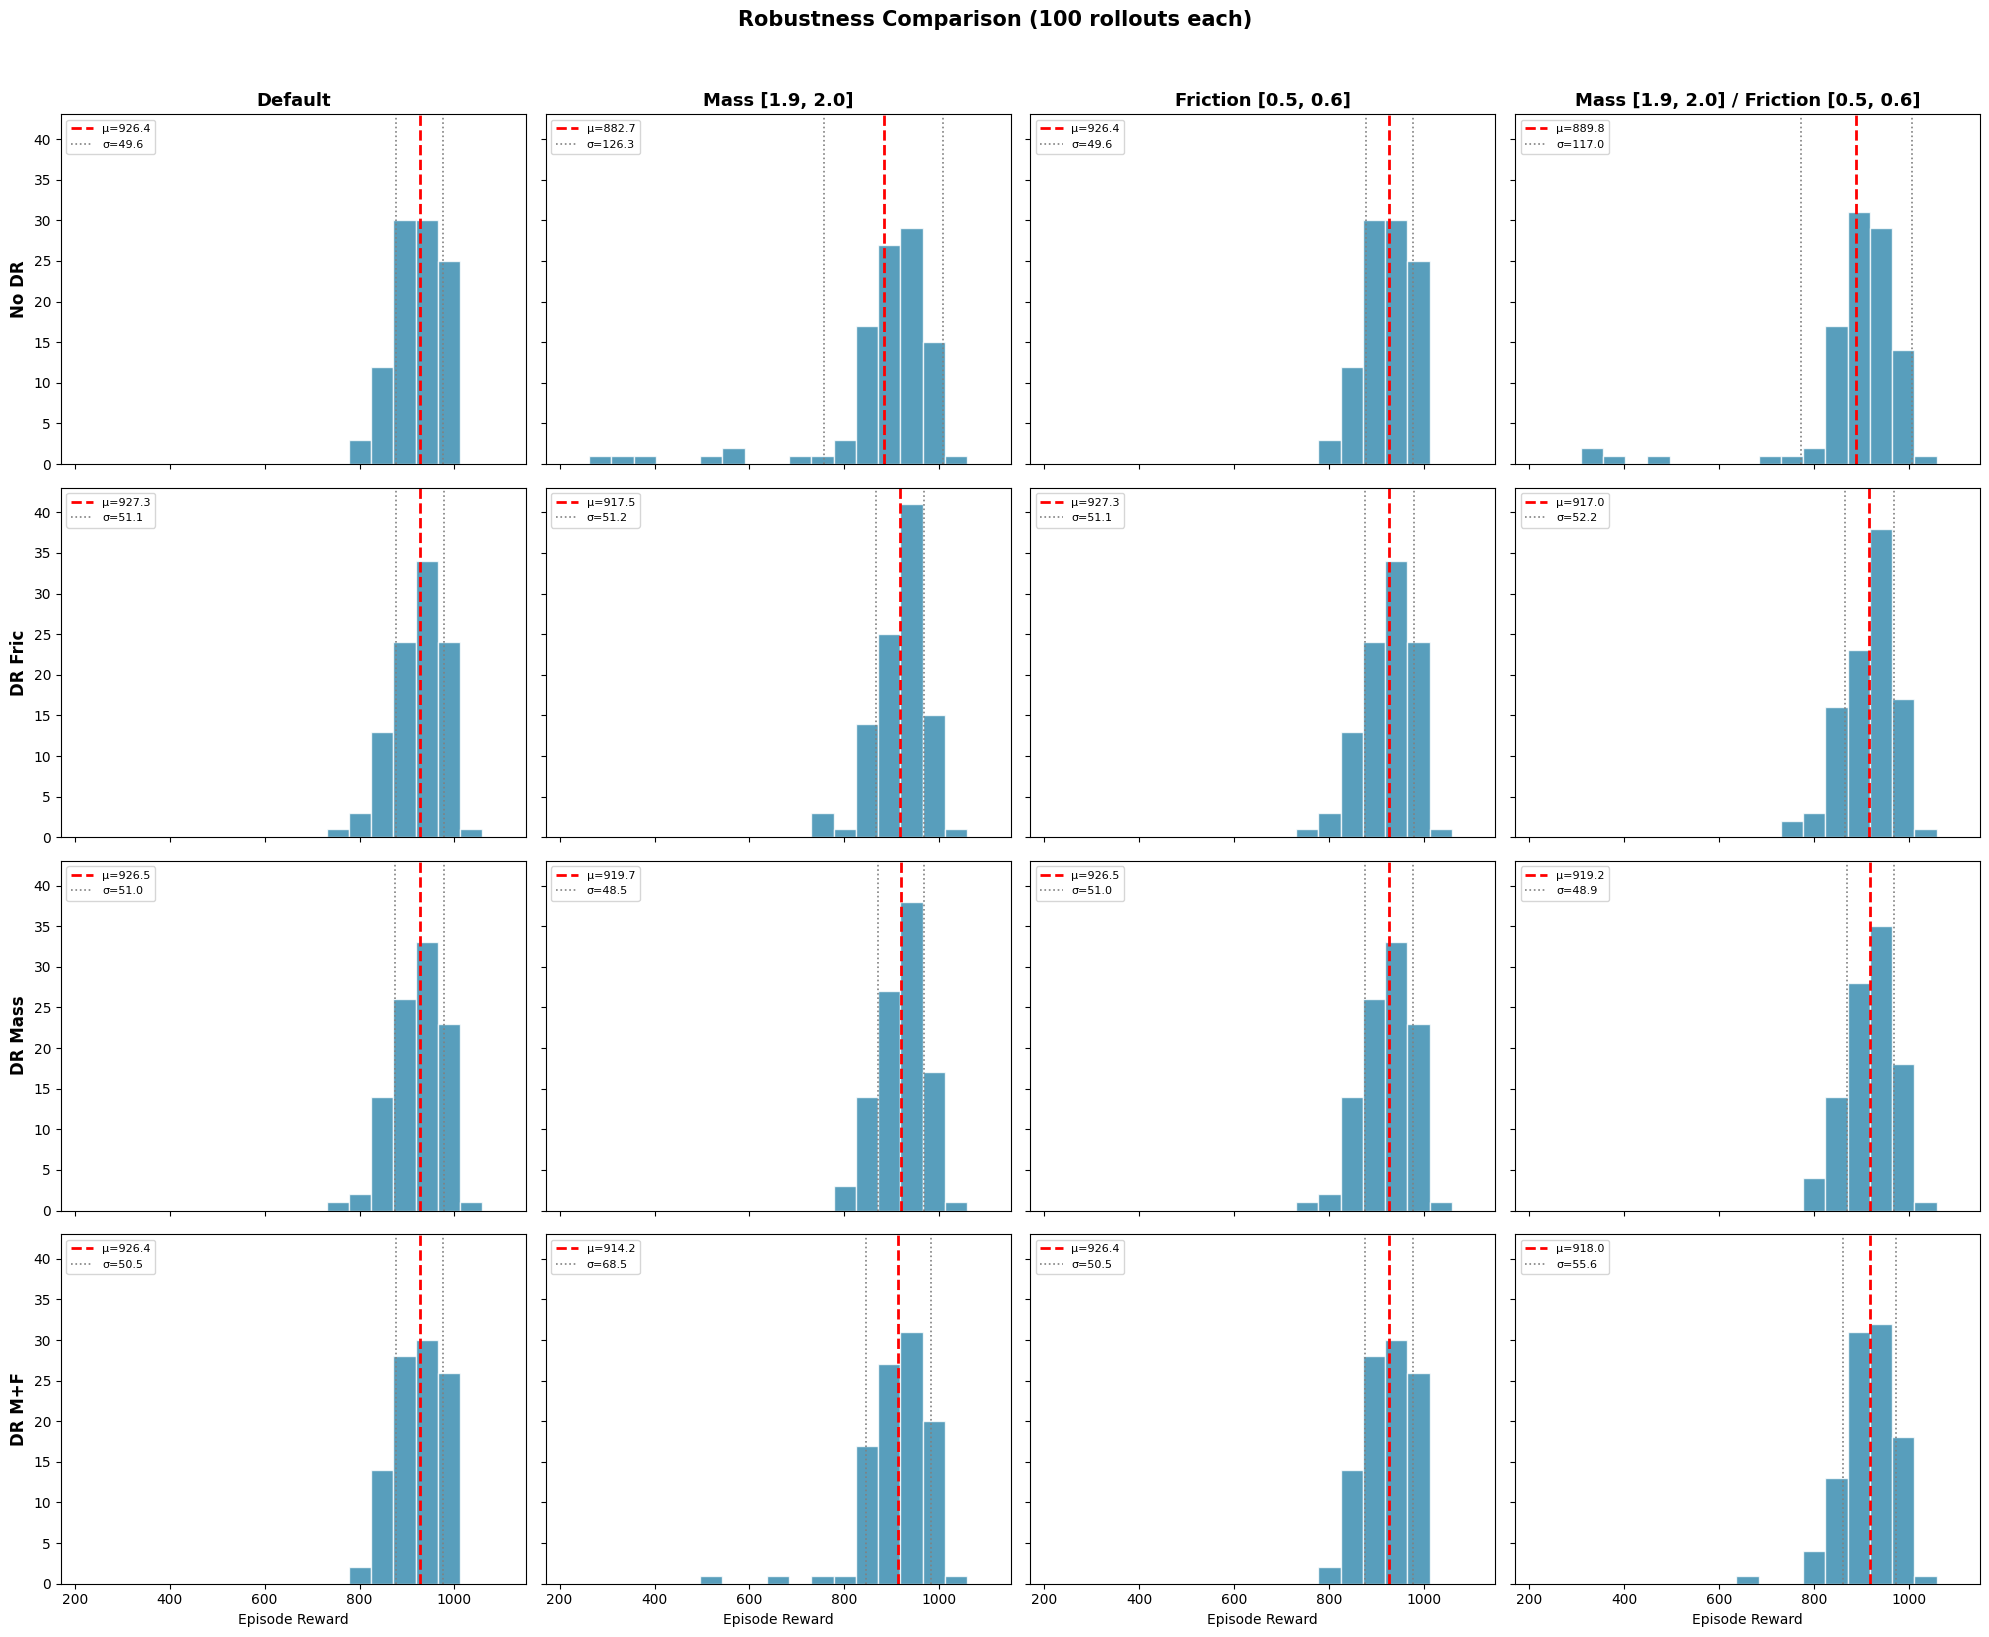

In [6]:
policy_labels = list(results.keys())
cond_labels = list(test_conditions.keys())
n_rows, n_cols = len(policy_labels), len(cond_labels)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows),
                         sharex=True, sharey=True, squeeze=False)

all_rewards = [r for p in results.values() for r in p.values()]
global_min = min(r.min() for r in all_rewards)
global_max = max(r.max() for r in all_rewards)
pad = (global_max - global_min) * 0.1
hist_bins = np.linspace(global_min - pad, global_max + pad, 20)

for row, plabel in enumerate(policy_labels):
    for col, clabel in enumerate(cond_labels):
        ax = axes[row][col]
        rews = results[plabel][clabel]

        ax.hist(rews, bins=hist_bins, color="#2E86AB", edgecolor="white", alpha=0.8)
        ax.axvline(rews.mean(), color="red", linestyle="--", linewidth=2,
                   label=f"μ={rews.mean():.1f}")
        ax.axvline(rews.mean() - rews.std(), color="gray", linestyle=":", linewidth=1.2)
        ax.axvline(rews.mean() + rews.std(), color="gray", linestyle=":", linewidth=1.2,
                   label=f"σ={rews.std():.1f}")
        ax.legend(fontsize=8)

        if row == 0:
            ax.set_title(clabel, fontsize=13, fontweight="bold")
        if col == 0:
            ax.set_ylabel(plabel, fontsize=12, fontweight="bold")
        if row == n_rows - 1:
            ax.set_xlabel("Episode Reward", fontsize=10)

fig.suptitle(f"Robustness Comparison ({num_rollouts} rollouts each)", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "robustness_histogram_grid.png"), dpi=300, bbox_inches="tight")
plt.show()

## 4. Training Reward Curves (2×2)

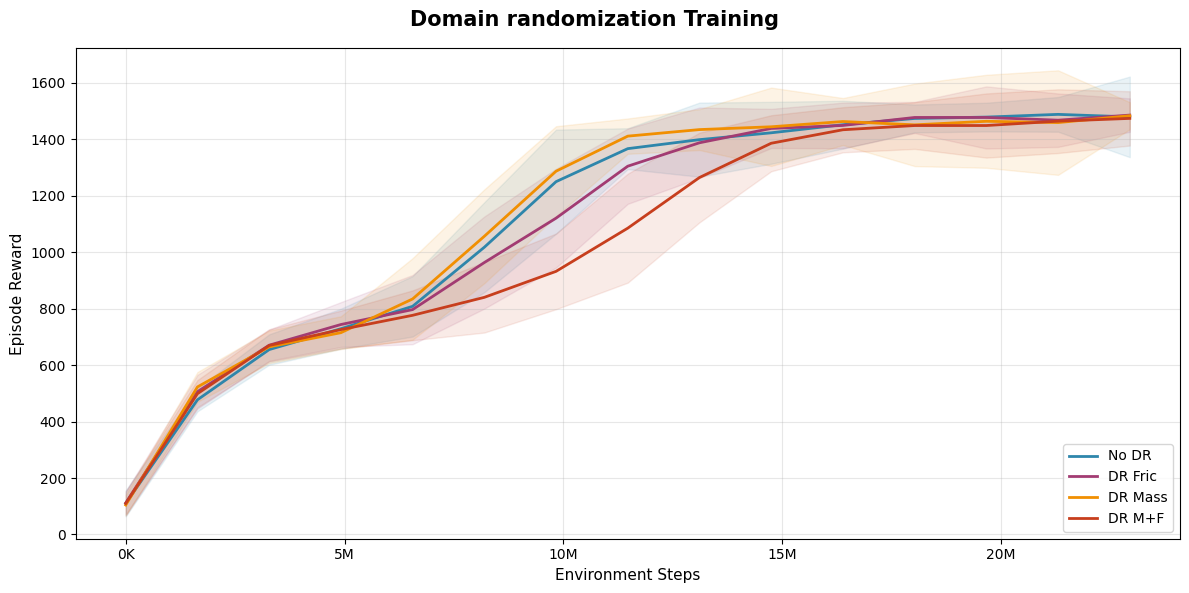

In [7]:
colors = ["#2E86AB", "#A23B72", "#F18F01", "#C73E1D"]

fig, ax = plt.subplots(figsize=(12, 6))

for idx, (label, run_id) in enumerate(policy_runs.items()):
    color = colors[idx]

    run = api.run(f"{user}/{project}/{run_id}")
    df = run.history(keys=["eval/episode_reward", "eval/episode_reward_std"]).dropna()

    steps = df["_step"].values
    mean = df["eval/episode_reward"].values
    std = df["eval/episode_reward_std"].values

    ax.plot(steps, mean, color=color, linewidth=2, label=label)
    ax.fill_between(steps, mean - std, mean + std, color=color, alpha=0.1)

ax.set_xlabel("Environment Steps", fontsize=11)
ax.set_ylabel("Episode Reward", fontsize=11)
ax.legend(fontsize=10, loc="lower right")
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{x/1e6:.0f}M" if x >= 1e6 else f"{x/1e3:.0f}K")
)

fig.suptitle("Domain randomization Training", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "training_curves_overlay.png"), dpi=300, bbox_inches="tight")
plt.show()

## 5. Single Rollout Visualization (optional)

In [8]:
# Pick one policy for detailed rollout
single_run_id = list(policy_runs.values())[0]
env = registry.load(env_name)
jit_reset = jax.jit(env.reset)
jit_step = jax.jit(env.step)
policy_fn = load_policy_from_run(single_run_id, env)

rng = jax.random.PRNGKey(42)
rng, reset_rng = jax.random.split(rng)
state = jit_reset(reset_rng)

rollout = [state]
total_reward = 0.0
step_rewards = []

for step in range(episode_length):
    rng, act_rng = jax.random.split(rng)
    act_out = policy_fn(state.obs, act_rng)
    action = act_out[0] if isinstance(act_out, tuple) else act_out
    state = jit_step(state, jnp.asarray(action))
    rollout.append(state)
    step_rewards.append(float(state.reward))
    total_reward += float(state.reward)

step_rewards = np.array(step_rewards)
print(f"Total reward: {total_reward:.2f}")
print(f"Step reward:  {step_rewards.mean():.4f} (mean), [{step_rewards.min():.4f}, {step_rewards.max():.4f}]")

# Render video
frames = env.render(rollout, camera="side_130", width=800, height=600)
frames = np.asarray(frames).astype(np.uint8)
mediapy.show_video(frames, fps=int(1.0 / env.dt))

✓ Using keyframe: 'low_home'
  Initial qpos size: 15
  Robot joints: [ 0.   -1.7   2.25 -2.15 -1.5  -1.5   0.    0.  ]
Available sensors:
  - left_finger_pad_floor_found
  - right_finger_pad_floor_found
  - hand_capsule_floor_found
  - box_hand_found
  - left_finger_box_contact
  - right_finger_box_contact
  - tcp_position
  - box_position


wandb:   2 of 2 files downloaded.  
/Users/matthiasweiss/miniconda3/envs/mujoco/lib/python3.10/site-packages/jax/_src/interpreters/xla.py:119: RuntimeWarning: overflow encountered in cast
  return np.asarray(x, dtypes.canonicalize_dtype(x.dtype))


Total reward: 929.23
Step reward:  9.2923 (mean), [1.3730, 11.7268]


100%|██████████| 101/101 [00:01<00:00, 87.94it/s]


This browser does not support the video tag.
